<a href="https://colab.research.google.com/github/vishw25bce10484-bit/Smart-Attendance-System-using-Face-Recognition/blob/main/ProjectVityarthiAI%26ML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2 # This is for all our computer vision stuff, like handling images and detection
import numpy as np # Great for working with numbers and arrays, which is how images are stored
from google.colab.output import eval_js # Lets us run JavaScript from our Python code in Colab
from base64 import b64decode # Helps us decode image data coming from JavaScript
from google.colab.patches import cv2_imshow # A special Colab function to show OpenCV images nicely
from IPython.display import display, Javascript # To display our JavaScript code so it actually runs

In [ ]:
def take_photo(filename='photo.jpg', quality=0.8):
  # This function uses some clever JavaScript to grab a picture from your webcam.
  # It'll save it as 'photo.jpg' by default and return that filename.
  js = Javascript('''
    async function takePhoto(quality) {
      // Setting up some basic HTML elements to show the camera feed and a capture button
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      // Asking for access to the user's camera stream
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      // Adding the video feed to the page so you can see yourself!
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Adjusting the Colab output area to fit the video
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Waiting for you to click the 'Capture' button
      await new Promise((resolve) => capture.onclick = resolve);

      // Once captured, we draw the video frame onto a canvas
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      // Shutting down the webcam stream and removing the video elements
      stream.getVideoTracks()[0].stop();
      div.remove();
      // Converting the canvas image to a JPEG format we can use
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js) # Displaying the JavaScript to run it
  # Running the JavaScript function and getting the image data back
  data = eval_js('takePhoto({})'.format(quality))
  # Decoding the image data from base64 to binary
  binary = b64decode(data.split(',')[1])
  # Saving the image to a file
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename # Giving back the name of the file we saved

Alright, so this whole thing is my dive into computer vision, figuring out how computers can 'see' and even 'recognize' faces. It's actually split into two main parts, which is pretty cool:

1.  **Just Finding Faces (General Face Detection):** This first bit is all about getting the computer to spot *any* face in a picture. You know, like if you're just trying to count how many people are in a photo, without caring who they are.
2.  **Knowing Who's Who (Specific Face Recognition):** This is where it gets a bit more personal! Here, I'm trying to make the computer actually recognize *specific individuals*. Think of it like getting the computer to remember your friends' faces and call them by name.

My aim with this project is to walk through how these technologies work, starting with the absolute basics and building up to an interactive system that can actually recognize people. So, let's jump in!

### Section 1: Kicking Things Off – The Essential Tools and Getting a Webcam Shot

First up, I've got to bring in all the Python libraries (think of them as toolkits) that I'll be using. They do a lot of the heavy lifting for things like image processing and running JavaScript. And speaking of JavaScript, I also cooked up a handy little function that lets me snap pictures straight from the webcam right here in the notebook. This is super important because it's how we'll feed live images into our face-seeing systems!

My `take_photo` function is actually a bit of a workaround for Colab, but it's brilliant! It uses some embedded JavaScript to get your webcam up and running. You'll see your own live video feed and a 'Capture' button. Once you hit it, snap! It grabs that frame, turns it into an image file, and gives me its name. This way, I can test everything out with fresh, live input whenever I want – pretty neat for a hands-on project!

### Section 2: First Step – Just Detecting *A* Face (Not Who It Is!)

Okay, so this section is where I tackle general face detection. My goal here isn't to identify *who* someone is, but just to tell, 'Yep, there's a face here!' I'm doing this using a pre-trained model from OpenCV's Deep Neural Network (DNN) module. It's basically a highly-trained 'brain' that already knows how to spot faces. I'll download its blueprint and its learned knowledge, then unleash it on a photo I take with the webcam.

In [ ]:
# Grabbing the architectural blueprint for our Caffe face detection model
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt

# Now, let's download the actual 'brain' (the trained weights) for our Caffe face detection model
!wget https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel

--2026-03-29 07:26:38--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28104 (27K) [text/plain]
Saving to: ‘deploy.prototxt.5’

deploy.prototxt.5   100%[===================>]  27.45K  --.-KB/s    in 0.002s  

2026-03-29 07:26:39 (16.3 MB/s) - ‘deploy.prototxt.5’ saved [28104/28104]

--2026-03-29 07:26:39--  https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HT

<IPython.core.display.Javascript object>

Saved to photo.jpg


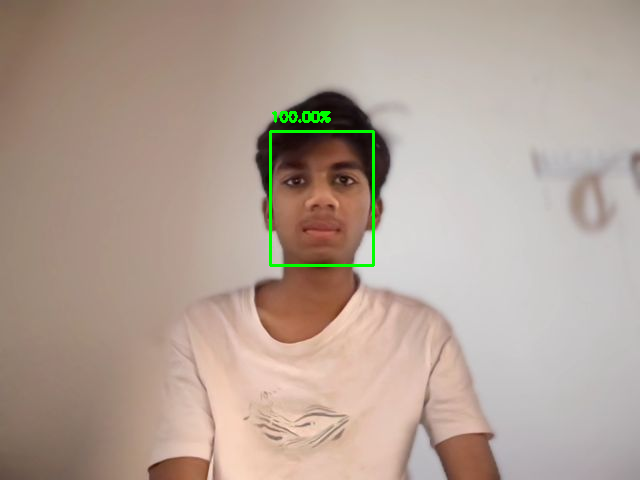

In [ ]:
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Loading up our pre-trained face detection model using the files we just downloaded
  model = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10_300x300_ssd_iter_140000.caffemodel")

  # Getting our captured image ready for the model
  image = cv2.imread(filename)
  (h, w) = image.shape[:2]
  # This `blobFromImage` part is crucial: it preprocesses our image to fit what the neural network expects
  blob = cv2.dnn.blobFromImage(cv2.resize(image, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))

  # Feeding the prepared image (blob) into the network to find faces
  model.setInput(blob)
  detections = model.forward()

  # Going through each detected face
  for i in range(0, detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    # We'll only care about detections that are pretty confident (over 50%)
    if confidence > 0.5:
      # Calculating the actual pixel coordinates for the bounding box around the face
      box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
      (startX, startY, endX, endY) = box.astype("int")

      # Drawing a nice green rectangle around the face and adding the confidence percentage
      text = "{:.2f}%".format(confidence * 100)
      y = startY - 10 if startY - 10 > 10 else startY + 10
      cv2.rectangle(image, (startX, startY), (endX, endY), (0, 255, 0), 2)
      cv2.putText(image, text, (startX, y), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 2)

  # Time to show off our detected faces!
  cv2_imshow(image)

except Exception as err:
  print(f"Oops, ran into an issue during face detection: {err}")

In [ ]:
# First, let's make sure we have the 'face_recognition' library installed – it's super handy!
!pip install face_recognition --quiet

import face_recognition # Our main tool for face recognition
import cv2 # Still useful for image processing
import numpy as np # For numerical operations
from IPython.display import Image, display # For showing images in Colab

### Section 3: The Big Step – Teaching the Computer *Who You Are*! (Specific Face Recognition)

Now, this is the really exciting bit – moving beyond just seeing faces to actually *recognizing specific people*. For this, I'm building a 'database' of known faces. The idea is simple: you take a picture of someone (maybe yourself!), tell the computer their name, and it stores their unique facial features.

This interactive part lets *you* play the role of the teacher. You capture a face with the webcam, type in a name, and bam! It's added to the system's memory. Once a face is 'known,' the computer can then try to find and identify that person in future photos. It's like building its own little social circle!

In [ ]:
known_face_encodings = [] # This list will hold the unique 'fingerprints' of faces we know
known_face_names = [] # And this list will store the names that go with those 'fingerprints'

# Let's start an interactive session to add some faces!
while True:
    add_face_choice = input("Want to teach the computer a new face? (yes/no): ").lower()
    if add_face_choice not in ['yes', 'y']:
        break # If you say no, we're done adding faces

    try:
        new_face_filename = take_photo() # Snap a picture using our webcam function
        print(f'Got a photo for a new face: {new_face_filename}')

        new_person_name = input("What's the name for this face?: ") # Asking for the person's name

        if not new_person_name.strip():
            print("Hmm, no name given. Skipping this one.")
            continue # Go back and ask again or finish up

        captured_image_for_new_face = face_recognition.load_image_file(new_face_filename)
        face_locations_new_face = face_recognition.face_locations(captured_image_for_new_face)

        if len(face_locations_new_face) > 0:
            # If we found a face, let's get its unique numerical 'encoding'
            new_face_encoding = face_recognition.face_encodings(captured_image_for_new_face, face_locations_new_face)[0]

            # Adding this new face's encoding and name to our lists
            known_face_encodings.append(new_face_encoding)
            known_face_names.append(new_person_name.strip())

            print(f"Awesome! We've added '{new_person_name}' to our known faces.")
        else:
            print("Couldn't find a face in that photo. Try again with a clearer shot!")

    except Exception as e:
        print(f"Something went wrong while adding a face: {e}")

print(f"All set with known faces! Here's who we know: {known_face_names}")

Want to teach the computer a new face? (yes/no): yes


<IPython.core.display.Javascript object>

Got a photo for a new face: photo.jpg
What's the name for this face?: vishw2
Awesome! We've added 'vishw2' to our known faces.
Want to teach the computer a new face? (yes/no): no
All set with known faces! Here's who we know: ['vishw2']


### Section 4: The Grand Finale – Recognizing Faces in a Brand New Photo!

Alright, this is the moment of truth! Now that I've built up my little database of known faces, let's see if the system can actually put names to the faces in a new picture. Here’s my plan of attack for this part:

1.  I'll **grab a fresh photo** from the webcam – gotta keep it real and current!
2.  Then, I'll have the system **find all the faces** in that new picture.
3.  For every face it spots, it'll **compare its unique features** against all the faces I've taught it to remember.
4.  Finally, I'll have it **draw boxes and labels** right on the photo. This way, we can immediately see if it's a 'Known' face (and who it is!) or if it's just an 'Unknown' person.

This whole process pretty much sums up what a face recognition system does at its core – it's like a digital detective for faces!

<IPython.core.display.Javascript object>

Captured photo: photo.jpg


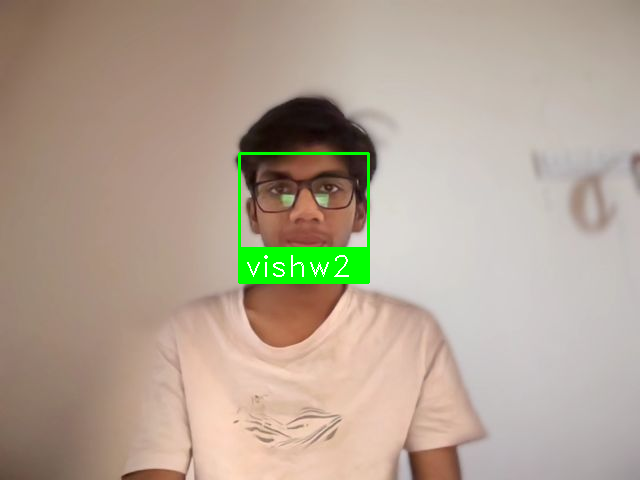

In [ ]:
if known_face_encodings: # Only run this if we actually have some faces to recognize!
    try:
        captured_filename = take_photo() # Take a new picture to see who's in it
        print(f'Captured photo: {captured_filename}')

        captured_image = face_recognition.load_image_file(captured_filename)
        face_locations = face_recognition.face_locations(captured_image)
        face_encodings = face_recognition.face_encodings(captured_image, face_locations)

        # Just a quick conversion: face_recognition uses RGB, but OpenCV (for showing images) likes BGR.
        captured_image_bgr = cv2.cvtColor(captured_image, cv2.COLOR_RGB2BGR);

        # Now, let's go through every face we found in this new picture
        for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
            # Comparing this face to all the faces we've saved as 'known'
            matches = face_recognition.compare_faces(known_face_encodings, face_encoding)

            name = "Unknown" # Default to 'Unknown' if we can't find a match

            # If we found a match, let's get the name!
            if True in matches:
                first_match_index = matches.index(True)
                name = known_face_names[first_match_index]

            # Drawing a green box around the face
            cv2.rectangle(captured_image_bgr, (left, top), (right, bottom), (0, 255, 0), 2);
            # And putting the name (or 'Unknown') on a green label below the box
            cv2.rectangle(captured_image_bgr, (left, bottom - 35), (right, bottom), (0, 255, 0), cv2.FILLED);
            font = cv2.FONT_HERSHEY_DUPLEX;
            cv2.putText(captured_image_bgr, name, (left + 6, bottom - 6), font, 1.0, (255, 255, 255), 1);

        cv2_imshow(captured_image_bgr); # Showing the final image with all the boxes and names!

    except Exception as e:
        print(f"Hmm, something went wrong during face recognition: {e}")
else:
    print("Can't recognize faces right now: we don't have any known faces loaded! Make sure to run the previous cell first.")